In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score


In [2]:
# LOAD DATA
df = pd.read_csv(r"C:\Users\waniu\Desktop\2026\2026\instafakeprofile.csv")
print(df.head(5))
print(df.tail(5))

   edge_followed_by  edge_follow  username_length  username_has_number  \
0             0.001        0.257               13                    1   
1             0.000        0.958                9                    1   
2             0.000        0.253               12                    0   
3             0.000        0.977               10                    1   
4             0.000        0.321               11                    0   

   full_name_has_number  full_name_length  is_private  is_joined_recently  \
0                     1                13           0                   0   
1                     0                 0           0                   1   
2                     0                 0           0                   0   
3                     0                 0           0                   0   
4                     0                11           1                   0   

   has_channel  is_business_account  has_guides  has_external_url  is_fake  
0            0 

In [3]:
#checking the shape and info of the dataset
print(df.shape)
print(df.info())

(785, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB
None


In [4]:
# #checking the null values
print(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)


edge_followed_by        0
edge_follow             0
username_length         0
username_has_number     0
full_name_has_number    0
full_name_length        0
is_private              0
is_joined_recently      0
has_channel             0
is_business_account     0
has_guides              0
has_external_url        0
is_fake                 0
dtype: int64
Number of duplicate rows: 3


In [5]:
print("Class Distribution:\n", df["is_fake"].value_counts())

Class Distribution:
 is_fake
1    692
0     93
Name: count, dtype: int64


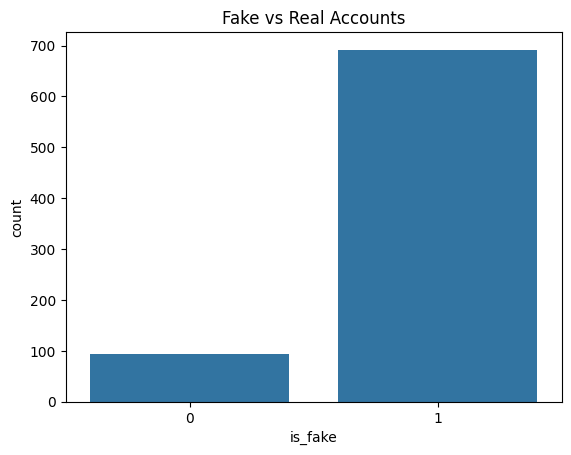

In [6]:
sns.countplot(x='is_fake', data=df)
plt.title("Fake vs Real Accounts")
plt.show()

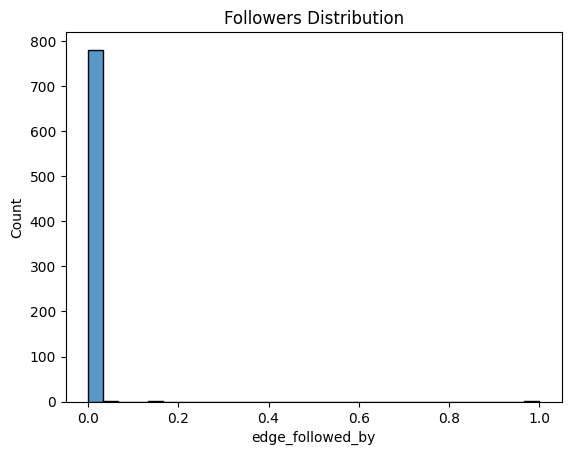

In [7]:
sns.histplot(df['edge_followed_by'], bins=30)
plt.title("Followers Distribution")
plt.show()

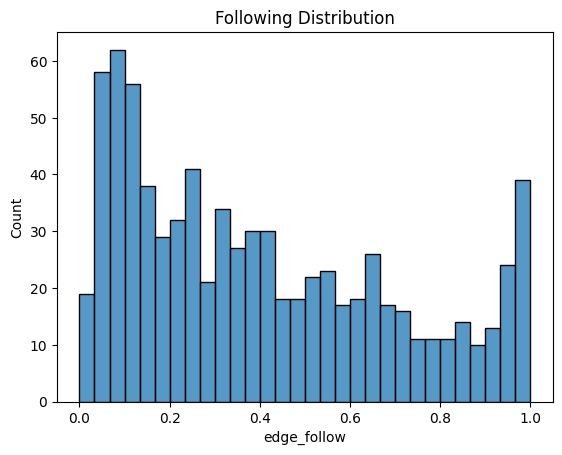

In [8]:
sns.histplot(df['edge_follow'], bins=30)
plt.title("Following Distribution")
plt.show()

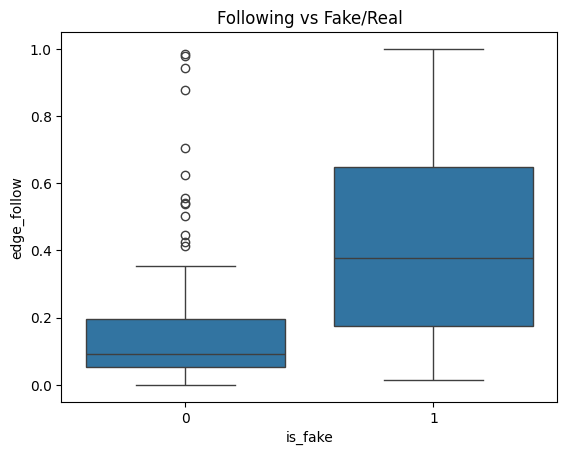

In [9]:
sns.boxplot(x='is_fake', y='edge_follow', data=df)
plt.title("Following vs Fake/Real")
plt.show()

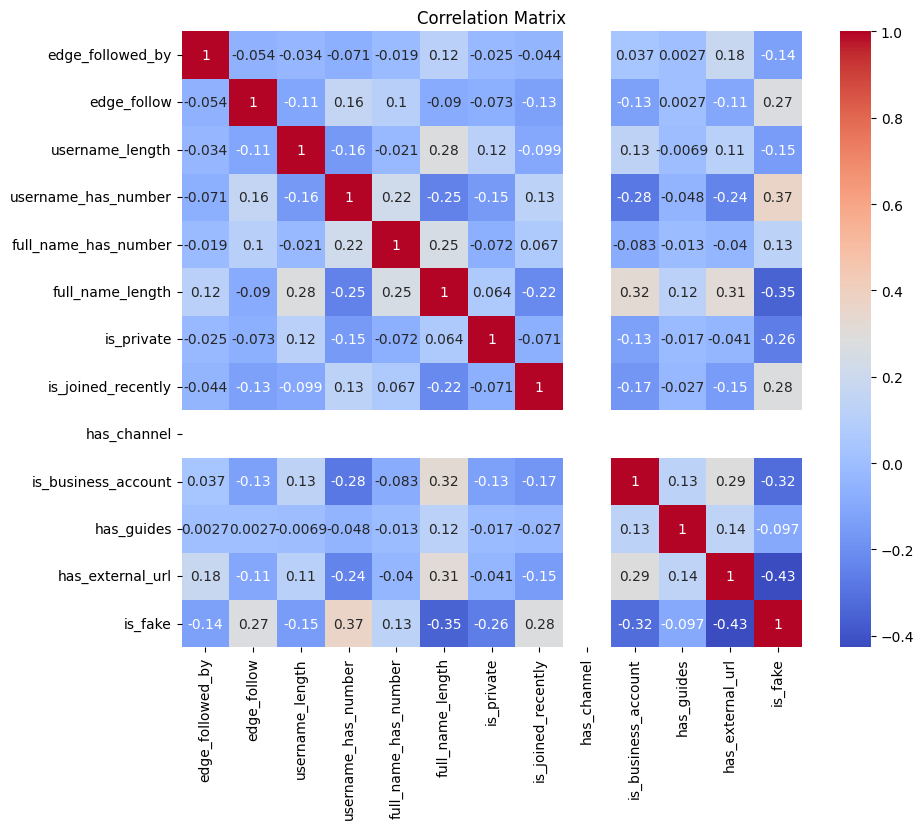

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
# FEATURES & TARGET
x = df.drop("is_fake", axis=1)
y = df["is_fake"]


In [12]:
#  TRAIN-TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# SMOTE
sm = SMOTE( random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)



In [14]:
#SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_sm)
x_test_scaled = scaler.transform(x_test)


Best LR Params: {'C': 0.1, 'solver': 'liblinear'}

Logistic Regression
Train Accuracy : 0.8908
Test Accuracy  : 0.8981
Precision: 0.9841269841269841
Recall   : 0.8985507246376812
F1 Score : 0.9393939393939394


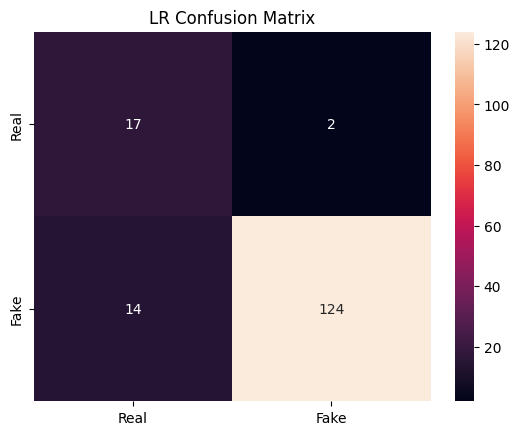

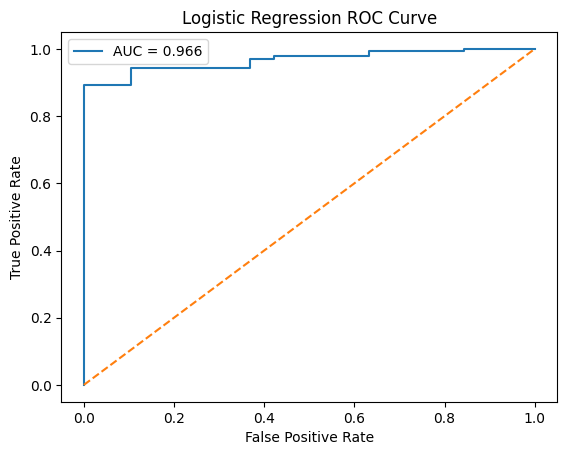

In [15]:
# LOGISTIC REGRESSION
param_lr = {
    'C': [0.01, 0.05, 0.1, 0.5, 1],
    'solver': ['lbfgs', 'liblinear'],
}

gs_lr = GridSearchCV(
    LogisticRegression(),
    param_lr,
    cv=5,
    scoring='f1'
)

gs_lr.fit(x_train_scaled, y_train_sm)
print("Best LR Params:", gs_lr.best_params_)

best_lr = gs_lr.best_estimator_

# Evaluation
train_pred = best_lr.predict(x_train_scaled)
test_pred = best_lr.predict(x_test_scaled)

print("\nLogistic Regression")
print(f"Train Accuracy : {accuracy_score(y_train_sm, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("LR Confusion Matrix")
plt.show()

# Probabilities
lr_probs = best_lr.predict_proba(x_test_scaled)[:, 1]

# ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = roc_auc_score(y_test, lr_probs)

# Plot
plt.figure()
plt.plot(lr_fpr, lr_tpr, label=f"AUC = {lr_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

Best SVM Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

SVM
Train Accuracy : 0.9233
Test Accuracy  : 0.8981
Precision: 0.9765625
Recall   : 0.9057971014492754
F1 Score : 0.9398496240601504


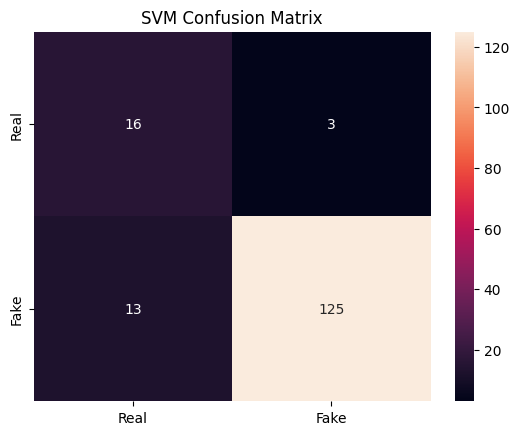

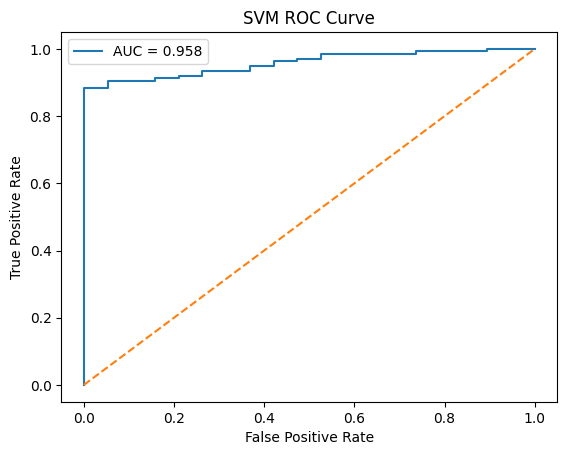

In [16]:
# SVM
param_svm = {
    'C': [0.1, 0.5, 1],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1],
}

gs_svm = GridSearchCV(
    SVC(probability=True),
    param_svm,
    cv=5,
    scoring='f1'
)

gs_svm.fit(x_train_scaled, y_train_sm)
print("Best SVM Params:", gs_svm.best_params_)

best_svm = gs_svm.best_estimator_

# Evaluation
train_pred = best_svm.predict(x_train_scaled)
test_pred = best_svm.predict(x_test_scaled)

print("\nSVM")
print(f"Train Accuracy : {accuracy_score(y_train_sm, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("SVM Confusion Matrix")
plt.show()

# Probabilities
svm_probs = best_svm.predict_proba(x_test_scaled)[:, 1]

# ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = roc_auc_score(y_test, svm_probs)

# Plot
plt.figure()
plt.plot(svm_fpr, svm_tpr, label=f"AUC = {svm_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

Best DT Params: {'min_samples_split': 13, 'min_samples_leaf': 6, 'max_depth': 6, 'criterion': 'gini'}

Decision Tree
Train Accuracy : 0.9657
Test Accuracy  : 0.9172
Precision: 0.9699248120300752
Recall   : 0.9347826086956522
F1 Score : 0.9520295202952029


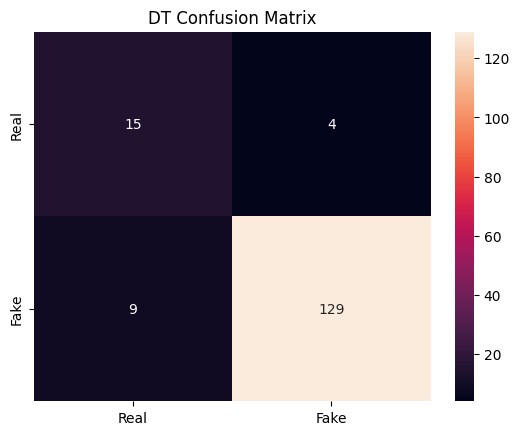

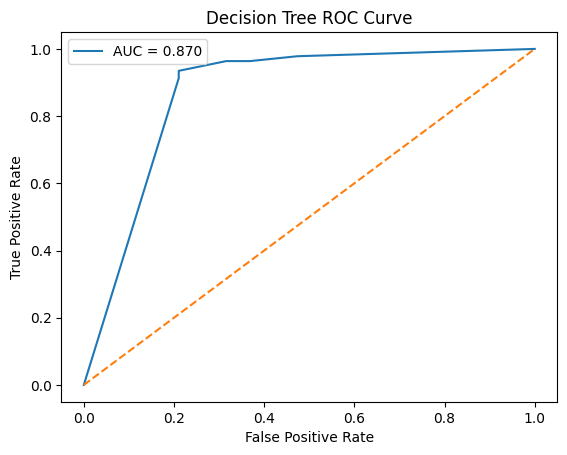

In [17]:
# DECISION TREE
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4,5,6],
    'min_samples_split': [12, 13, 15],
    'min_samples_leaf': [6, 7, 8]
}

rs_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    n_iter=5,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_dt.fit(x_train_sm, y_train_sm)
print("Best DT Params:", rs_dt.best_params_)

best_dt = rs_dt.best_estimator_

# Evaluation
train_pred = best_dt.predict(x_train_sm)
test_pred = best_dt.predict(x_test)

print("\nDecision Tree")
print(f"Train Accuracy : {accuracy_score(y_train_sm, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("DT Confusion Matrix")
plt.show()

# Probabilities
dt_probs = best_dt.predict_proba(x_test)[:, 1]

# ROC
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Plot
plt.figure()
plt.plot(dt_fpr, dt_tpr, label=f"AUC = {dt_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()


Best RF Params: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 8}

Random Forest
Train Accuracy : 0.9639
Test Accuracy  : 0.9172
Precision: 0.9699248120300752
Recall   : 0.9347826086956522
F1 Score : 0.9520295202952029


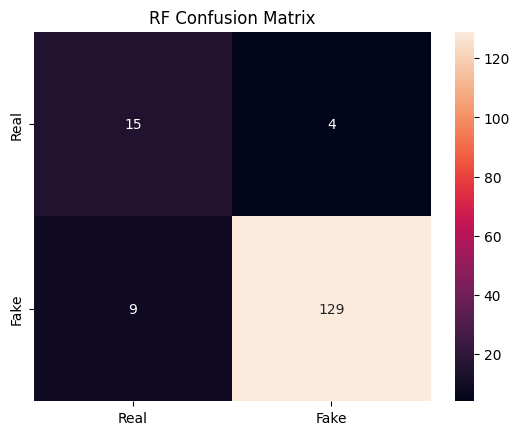

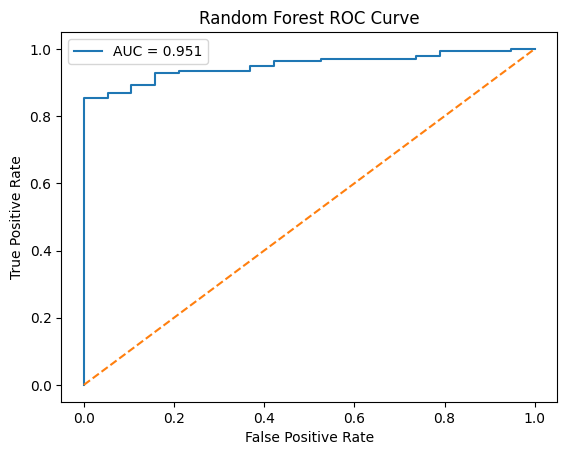

In [18]:
# RANDOM FOREST
param_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [5, 7, 10],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.6, 0.7],
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_rf.fit(x_train_sm, y_train_sm)
print("Best RF Params:", rs_rf.best_params_)

best_rf = rs_rf.best_estimator_

# Evaluation
train_pred = best_rf.predict(x_train_sm)
test_pred = best_rf.predict(x_test)

print("\nRandom Forest")
print(f"Train Accuracy : {accuracy_score(y_train_sm, train_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

print("Precision:", precision_score(y_test, test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title("RF Confusion Matrix")
plt.show()


# Probabilities
rf_probs = best_rf.predict_proba(x_test)[:, 1]

# ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# Plot
plt.figure()
plt.plot(rf_fpr, rf_tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()